# TCN + BiGRU + XGBoost -- CMAPSS Failure Prediction (Improved, paper-ready protocol)

**Pipeline:**
1. Train-only IQR outlier removal before scaling
2. Sliding-window sequence construction for train/validation
3. **TCN + BiGRU + Attention** encoder
4. **Hybrid loss**: focal classification + MSE reconstruction self-supervision
5. **Feature fusion**: deep embedding + 12-statistic semantic trend features
6. Leakage-free GridSearchCV on **train only**; validation is reserved for threshold and smoothing selection
7. **Business-aware threshold** selected on validation only
8. **Decision mode** (window vs engine smoothing) selected on validation only
9. **Dual test reporting**: `last` protocol for CMAPSS literature comparison and `sliding` protocol for operational full-timeline evaluation

All four CMAPSS datasets (FD001-FD004) are supported via `CFG['dataset']`.

In [53]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [54]:
import numpy as np
import pandas as pd
import os, warnings, random
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, fbeta_score, recall_score, roc_auc_score,
    classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score, roc_curve,
    make_scorer,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold

import xgboost as xgb
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(42)

Device: cuda


## Configuration

In [55]:
BASE = '/content/drive/MyDrive/data'

CFG = {
    # --- Data ---
    'dataset'          : 'FD001',   # FD001 | FD002 | FD003 | FD004
    'rul_threshold'    : 30,
    'seq_len'          : 40,
    'stride'           : 1,
    'val_engine_frac'  : 0.15,
    'remove_outliers'  : True,
    'outlier_iqr_k'    : 3.0,
    'outlier_min_hits' : 2,

    # --- TCN ---
    'tcn_channels'     : [64, 128, 128, 64],
    'tcn_kernel'       : 3,
    'tcn_dropout'      : 0.2,

    # --- BiGRU ---
    'gru_hidden'       : 128,
    'gru_layers'       : 2,
    'gru_dropout'      : 0.3,

    # --- Embedding ---
    'embed_dim'        : 128,

    # --- Training ---
    'epochs'           : 60,
    'batch_size'       : 256,
    'lr'               : 1e-3,
    'weight_decay'     : 1e-4,
    'patience'         : 12,
    'focal_gamma'      : 2.5,
    'recon_weight'     : 0.1,        # hybrid loss alpha for MSE reconstruction

    # --- Recall-boost ---
    'pos_weight_boost' : 2.0,
    'recall_beta'      : 2.0,

    # --- Test-time evaluation ---
    # Both protocols are always built and reported.
    # 'last'   : one window per test engine; CMAPSS literature-comparable protocol
    # 'sliding': all available test windows; operational full-timeline protocol
    'test_protocols'        : ['last', 'sliding'],
    'primary_test_protocol' : 'last',
    'use_engine_smoothing'  : True,
    'use_semantic_features' : True,

    # --- Business-aware threshold ---
    'min_precision'    : 0.70,
    'f1_tolerance'     : 0.005,

    # --- Engine-smoothing search grid ---
    'ma_k_grid'        : [3, 5, 7],
    'persist_grid'     : [(2, 1), (3, 1), (3, 2), (4, 2)],

    # --- XGBoost base defaults ---
    'xgb_rounds'       : 800,
    'xgb_lr'           : 0.03,
    'xgb_depth'        : 6,
    'xgb_subsample'    : 0.8,
    'xgb_colsample'    : 0.8,
    'xgb_min_child'    : 3,
    'xgb_alpha'        : 0.1,
    'xgb_lambda'       : 1.0,
    'xgb_es_rounds'    : 40,

    # --- GridSearchCV ---
    'grid_cv_folds'    : 3,
    'grid_n_jobs'      : -1,

    # --- Optional article experiments ---
    'ablation_fd'      : 'FD001',
    'ablation_enabled' : False,
    'seed_list'        : [42, 123, 2024],
    'recon_weight_grid': [0.0, 0.1, 0.3, 0.5, 1.0],
}

## Data Loading and Preprocessing

In [56]:
COLUMNS = (
    ['unit_number', 'time_in_cycles']
    + [f'op_{i}' for i in range(1, 4)]
    + [f's{i}'  for i in range(1, 22)]
)

# Sensors with near-zero variance (uninformative)
DROP_SENSORS = ['s1', 's5', 's6', 's10', 's16', 's18', 's19']


def load_raw(fd):
    train = pd.read_csv(f'{BASE}/train_{fd}.txt', sep=r'\s+', header=None, names=COLUMNS)
    test  = pd.read_csv(f'{BASE}/test_{fd}.txt',  sep=r'\s+', header=None, names=COLUMNS)
    rul   = pd.read_csv(f'{BASE}/RUL_{fd}.txt',   header=None, names=['RUL'])
    return train, test, rul


def add_train_rul(df):
    max_c = df.groupby('unit_number')['time_in_cycles'].max()
    df = df.join(max_c.rename('max_c'), on='unit_number')
    df['RUL'] = df['max_c'] - df['time_in_cycles']
    return df.drop('max_c', axis=1)


def add_test_rul(test_df, rul_df):
    """Per-step RUL for test rows, computed from trailing RUL table."""
    test_df = test_df.copy()
    max_c = test_df.groupby('unit_number')['time_in_cycles'].max().reset_index()
    max_c.columns = ['unit_number', 'max_c']
    rul = rul_df.copy()
    rul['unit_number'] = np.arange(1, len(rul) + 1)
    max_c = max_c.merge(rul, on='unit_number', how='left')
    max_c['final_cycle'] = max_c['max_c'] + max_c['RUL']
    test_df = test_df.merge(max_c[['unit_number', 'final_cycle']],
                            on='unit_number', how='left')
    test_df['RUL'] = test_df['final_cycle'] - test_df['time_in_cycles']
    return test_df.drop('final_cycle', axis=1)


def get_features(df):
    drop = ['unit_number', 'time_in_cycles', 'RUL'] + DROP_SENSORS
    return [c for c in df.columns if c not in drop]


def split_train_val(train_df, val_frac, seed=42):
    units = train_df['unit_number'].unique()
    rng   = np.random.RandomState(seed)
    val_units = rng.choice(units, size=int(len(units) * val_frac), replace=False)
    val_mask  = train_df['unit_number'].isin(val_units)
    return train_df[~val_mask].copy(), train_df[val_mask].copy()


def fit_outlier_bounds(train_df, feat_cols, iqr_k=3.0):
    """Fit sensor outlier bounds on train data only."""
    outlier_cols = [c for c in feat_cols if c.startswith('s')]
    if not outlier_cols:
        empty = pd.Series(dtype=np.float32)
        return outlier_cols, empty, empty
    q1 = train_df[outlier_cols].quantile(0.25)
    q3 = train_df[outlier_cols].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - iqr_k * iqr
    upper = q3 + iqr_k * iqr
    zero_iqr = iqr == 0
    lower.loc[zero_iqr] = q1.loc[zero_iqr]
    upper.loc[zero_iqr] = q3.loc[zero_iqr]
    return outlier_cols, lower.astype(np.float32), upper.astype(np.float32)


def remove_train_outliers(train_df, outlier_cols, lower, upper, min_hits=2):
    """Remove rows with multiple train-fitted sensor outlier flags."""
    if not outlier_cols:
        return train_df.copy(), 0, 0.0
    flags = train_df[outlier_cols].lt(lower, axis=1) | train_df[outlier_cols].gt(upper, axis=1)
    outlier_mask = flags.sum(axis=1) >= min_hits
    clean_df = train_df.loc[~outlier_mask].copy()
    return clean_df, int(outlier_mask.sum()), float(outlier_mask.mean())


def clip_to_outlier_bounds(df, outlier_cols, lower, upper):
    """Clip held-out values to train-fitted bounds without dropping evaluation rows."""
    if not outlier_cols:
        return df.copy()
    clipped = df.copy()
    clipped.loc[:, outlier_cols] = clipped[outlier_cols].clip(lower=lower, upper=upper, axis=1)
    return clipped


def make_sliding_windows(df, feat_cols, seq_len, stride, threshold):
    """Sliding-window sequences with per-window engine ids."""
    X_list, y_list, eng_list = [], [], []
    for uid, group in df.groupby('unit_number'):
        group  = group.sort_values('time_in_cycles')
        arr    = group[feat_cols].values.astype(np.float32)
        labels = (group['RUL'].values < threshold).astype(np.int64)
        T = len(arr)
        if T < seq_len:
            continue
        for start in range(0, T - seq_len + 1, stride):
            end = start + seq_len
            X_list.append(arr[start:end])
            y_list.append(labels[end - 1])
            eng_list.append(int(uid))
    return (np.array(X_list, dtype=np.float32),
            np.array(y_list, dtype=np.int64),
            np.array(eng_list, dtype=np.int64))


def make_test_windows_last(test_df, rul_df, feat_cols, seq_len, threshold):
    """Classic CMAPSS test protocol: one last window per test engine."""
    X_list, y_list, eng_list = [], [], []
    for idx, (uid, group) in enumerate(test_df.groupby('unit_number')):
        group = group.sort_values('time_in_cycles')
        arr = group[feat_cols].values.astype(np.float32)
        if len(arr) >= seq_len:
            window = arr[-seq_len:]
        else:
            pad    = np.zeros((seq_len - len(arr), arr.shape[1]), dtype=np.float32)
            window = np.vstack([pad, arr])
        true_rul = rul_df.iloc[idx]['RUL']
        X_list.append(window)
        y_list.append(int(true_rul < threshold))
        eng_list.append(int(uid))
    return (np.array(X_list, dtype=np.float32),
            np.array(y_list, dtype=np.int64),
            np.array(eng_list, dtype=np.int64))


# Load
FD = CFG['dataset']
train_raw, test_raw, rul_raw = load_raw(FD)
train_raw = add_train_rul(train_raw)
test_raw  = add_test_rul(test_raw, rul_raw)

# Engine-level split (no leakage)
tr_df, val_df = split_train_val(train_raw, CFG['val_engine_frac'])
feat_cols = get_features(tr_df)
print(f'Features ({len(feat_cols)}): {feat_cols}')

# Outlier removal (fit bounds on train only, preserve val/test rows)
if CFG.get('remove_outliers', True):
    out_cols, out_lower, out_upper = fit_outlier_bounds(
        tr_df, feat_cols, iqr_k=CFG.get('outlier_iqr_k', 3.0))
    before_rows = len(tr_df)
    tr_df, out_removed, out_frac = remove_train_outliers(
        tr_df, out_cols, out_lower, out_upper, min_hits=CFG.get('outlier_min_hits', 2))
    val_df = clip_to_outlier_bounds(val_df, out_cols, out_lower, out_upper)
    test_raw = clip_to_outlier_bounds(test_raw, out_cols, out_lower, out_upper)
    print(f'Outlier removal: dropped {out_removed}/{before_rows} train rows '
          f'({out_frac:.2%}); clipped val/test to train bounds')

# Standardise (fit on train only)
scaler = StandardScaler()
tr_df[feat_cols]    = scaler.fit_transform(tr_df[feat_cols])
val_df[feat_cols]   = scaler.transform(val_df[feat_cols])
test_raw[feat_cols] = scaler.transform(test_raw[feat_cols])

# Build train/validation windows, then build BOTH test protocols every run.
SL, ST, TH = CFG['seq_len'], CFG['stride'], CFG['rul_threshold']
X_tr,  y_tr,  eng_tr  = make_sliding_windows(tr_df,  feat_cols, SL, ST, TH)
X_val, y_val, eng_val = make_sliding_windows(val_df, feat_cols, SL, ST, TH)

X_te_last, y_te_last, eng_te_last = make_test_windows_last(test_raw, rul_raw, feat_cols, SL, TH)
X_te_sl,   y_te_sl,   eng_te_sl   = make_sliding_windows(test_raw, feat_cols, SL, ST, TH)

TEST_WINDOWS = {
    'last': {
        'X': X_te_last,
        'y': y_te_last,
        'engine': eng_te_last,
        'description': 'one last window per test engine',
    },
    'sliding': {
        'X': X_te_sl,
        'y': y_te_sl,
        'engine': eng_te_sl,
        'description': 'all sliding windows across the test timeline',
    },
}

print(f'Train        : {X_tr.shape} | pos ratio: {y_tr.mean():.3f}')
print(f'Val          : {X_val.shape} | pos ratio: {y_val.mean():.3f}')
for protocol, data in TEST_WINDOWS.items():
    print(f'Test {protocol:<7}: {data["X"].shape} | pos ratio: {data["y"].mean():.3f} | '
          f'engines: {len(np.unique(data["engine"]))} | {data["description"]}')

Features (17): ['op_1', 'op_2', 'op_3', 's2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
Outlier removal: dropped 594/17569 train rows (3.38%); clipped val/test to train bounds
Train        : (13660, 40, 17) | pos ratio: 0.146
Val          : (2477, 40, 17) | pos ratio: 0.182
Test last   : (100, 40, 17) | pos ratio: 0.250 | engines: 100 | one last window per test engine
Test sliding: (9211, 40, 17) | pos ratio: 0.033 | engines: 96 | all sliding windows across the test timeline


## Model: TCN + BiGRU + Attention

In [57]:
class CausalConvBlock(nn.Module):
    """Single dilated causal conv block (WeightNorm + residual)."""
    def __init__(self, in_ch, out_ch, kernel, dilation, dropout):
        super().__init__()
        pad = (kernel - 1) * dilation
        self.conv1 = nn.utils.weight_norm(
            nn.Conv1d(in_ch, out_ch, kernel, padding=pad, dilation=dilation))
        self.conv2 = nn.utils.weight_norm(
            nn.Conv1d(out_ch, out_ch, kernel, padding=pad, dilation=dilation))
        self.drop  = nn.Dropout(dropout)
        self.relu  = nn.ReLU()
        self.res   = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None

    def forward(self, x):
        out = self.relu(self.conv1(x)[:, :, :x.size(2)])
        out = self.drop(out)
        out = self.relu(self.conv2(out)[:, :, :x.size(2)])
        out = self.drop(out)
        res = x if self.res is None else self.res(x)
        return self.relu(out + res)


class TCN(nn.Module):
    """Dilated TCN -- dilation doubles each layer (2^i)."""
    def __init__(self, in_ch, channels, kernel, dropout):
        super().__init__()
        layers = []
        for i, out_ch in enumerate(channels):
            layers.append(CausalConvBlock(in_ch, out_ch, kernel,
                                          dilation=2**i, dropout=dropout))
            in_ch = out_ch
        self.net = nn.Sequential(*layers)

    def forward(self, x):           # x: (B, T, C_in)
        x = x.permute(0, 2, 1)     # -> (B, C, T)
        x = self.net(x)
        return x.permute(0, 2, 1)  # -> (B, T, C_out)


class AttentionPool(nn.Module):
    """Additive attention: compress sequence to a single vector."""
    def __init__(self, hidden):
        super().__init__()
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):                          # x: (B, T, H)
        w = torch.softmax(self.fc(x), dim=1)       # (B, T, 1)
        return (w * x).sum(dim=1)                  # (B, H)


class TCNBiGRU(nn.Module):
    """TCN+BiGRU+Attention encoder with two heads:
       cls_head  : binary failure logit (focal loss)
       recon_head: reconstruct last-timestep features (MSE, hybrid SSL regularizer)
    """
    def __init__(self, n_feat, cfg):
        super().__init__()
        self.tcn = TCN(n_feat, cfg['tcn_channels'], cfg['tcn_kernel'], cfg['tcn_dropout'])
        tcn_out  = cfg['tcn_channels'][-1]

        self.bigru = nn.GRU(
            input_size    = tcn_out,
            hidden_size   = cfg['gru_hidden'],
            num_layers    = cfg['gru_layers'],
            batch_first   = True,
            bidirectional = True,
            dropout       = cfg['gru_dropout'] if cfg['gru_layers'] > 1 else 0,
        )
        gru_out = cfg['gru_hidden'] * 2

        self.attn = AttentionPool(gru_out)
        self.proj = nn.Sequential(
            nn.Linear(gru_out, cfg['embed_dim']),
            nn.LayerNorm(cfg['embed_dim']),
            nn.GELU(),
            nn.Dropout(0.2),
        )
        self.cls_head   = nn.Linear(cfg['embed_dim'], 1)
        self.recon_head = nn.Sequential(
            nn.Linear(cfg['embed_dim'], 64),
            nn.ReLU(),
            nn.Linear(64, n_feat),
        )

    def embed(self, x):
        t, _ = self.bigru(self.tcn(x))
        return self.proj(self.attn(t))

    def forward(self, x):
        z = self.embed(x)
        return self.cls_head(z).squeeze(-1), self.recon_head(z), z


n_feat = X_tr.shape[2]
model  = TCNBiGRU(n_feat, CFG).to(DEVICE)
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Trainable parameters: 732,051


## Focal Loss + Training Loop

In [58]:
class FocalLoss(nn.Module):
    """Focal loss (BCE-based) to handle class imbalance."""
    def __init__(self, gamma=2.0, pos_weight=None):
        super().__init__()
        self.gamma = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits, targets.float(), pos_weight=self.pos_weight, reduction='none')
        prob = torch.sigmoid(logits)
        pt   = torch.where(targets == 1, prob, 1 - prob)
        return ((1 - pt) ** self.gamma * bce).mean()


def get_loader(X, y, batch_size, shuffle=True):
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, pin_memory=True)


# Boost pos_weight to push the encoder toward higher recall
raw_pos_ratio = float((y_tr == 0).sum() / (y_tr == 1).sum())
boosted_pw    = raw_pos_ratio * CFG['pos_weight_boost']
pos_w = torch.tensor([boosted_pw], dtype=torch.float32).to(DEVICE)
print(f'Focal loss pos_weight: {raw_pos_ratio:.2f} x {CFG["pos_weight_boost"]} = {boosted_pw:.2f}')

cls_criterion   = FocalLoss(gamma=CFG['focal_gamma'], pos_weight=pos_w)
recon_criterion = nn.MSELoss()
RECON_W         = CFG['recon_weight']

optimizer = torch.optim.AdamW(model.parameters(), lr=CFG['lr'],
                               weight_decay=CFG['weight_decay'])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG['epochs'], eta_min=1e-5)

tr_loader  = get_loader(X_tr,  y_tr,  CFG['batch_size'], shuffle=True)
val_loader = get_loader(X_val, y_val, CFG['batch_size'], shuffle=False)

BETA = CFG['recall_beta']

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, preds, trues = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits, recon, _ = model(xb)
            cls_loss   = cls_criterion(logits, yb)
            recon_loss = recon_criterion(recon, xb[:, -1, :])   # last timestep targets
            loss = cls_loss + RECON_W * recon_loss
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * len(xb)
            preds.extend(torch.sigmoid(logits).detach().cpu().numpy())
            trues.extend(yb.detach().cpu().numpy())
    preds, trues = np.array(preds), np.array(trues)
    fb  = fbeta_score(trues, (preds > 0.5).astype(int), beta=BETA, zero_division=0)
    auc = roc_auc_score(trues, preds) if len(np.unique(trues)) > 1 else 0.5
    return total_loss / len(trues), fb, auc


print(f'Hybrid training (focal + {RECON_W}*recon, F{BETA:.0f} early-stop)...')
best_val_fb, best_state, no_improve = -1.0, None, 0
history = {'tr_loss':[], 'val_loss':[], 'tr_f1':[], 'val_f1':[], 'val_auc':[]}

for ep in range(1, CFG['epochs'] + 1):
    tr_loss,  tr_fb,  _       = run_epoch(tr_loader,  train=True)
    val_loss, val_fb, val_auc = run_epoch(val_loader, train=False)
    scheduler.step()
    history['tr_loss'].append(tr_loss);   history['val_loss'].append(val_loss)
    history['tr_f1'].append(tr_fb);       history['val_f1'].append(val_fb)
    history['val_auc'].append(val_auc)
    if val_fb > best_val_fb:
        best_val_fb = val_fb
        best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        no_improve  = 0
    else:
        no_improve += 1
    if ep % 5 == 0 or ep == 1:
        print(f'Epoch {ep:3d} | tr_loss={tr_loss:.4f} tr_F{BETA:.0f}={tr_fb:.4f} | '
              f'val_loss={val_loss:.4f} val_F{BETA:.0f}={val_fb:.4f} val_auc={val_auc:.4f}')
    if no_improve >= CFG['patience']:
        print(f'Early stopping at epoch {ep}')
        break

model.load_state_dict(best_state)
print(f'\nBest val F{BETA:.0f}: {best_val_fb:.4f}')

Focal loss pos_weight: 5.84 x 2.0 = 11.67
Hybrid training (focal + 0.1*recon, F2 early-stop)...
Epoch   1 | tr_loss=0.2152 tr_F2=0.7638 | val_loss=0.1181 val_F2=0.8969 val_auc=0.9930
Epoch   5 | tr_loss=0.0667 tr_F2=0.9492 | val_loss=0.0940 val_F2=0.9335 val_auc=0.9954
Epoch  10 | tr_loss=0.0465 tr_F2=0.9771 | val_loss=0.1345 val_F2=0.9296 val_auc=0.9947
Epoch  15 | tr_loss=0.0405 tr_F2=0.9885 | val_loss=0.2025 val_F2=0.9230 val_auc=0.9938
Epoch  20 | tr_loss=0.0370 tr_F2=0.9908 | val_loss=0.2553 val_F2=0.9193 val_auc=0.9918
Early stopping at epoch 20

Best val F2: 0.9371


## Training Curves

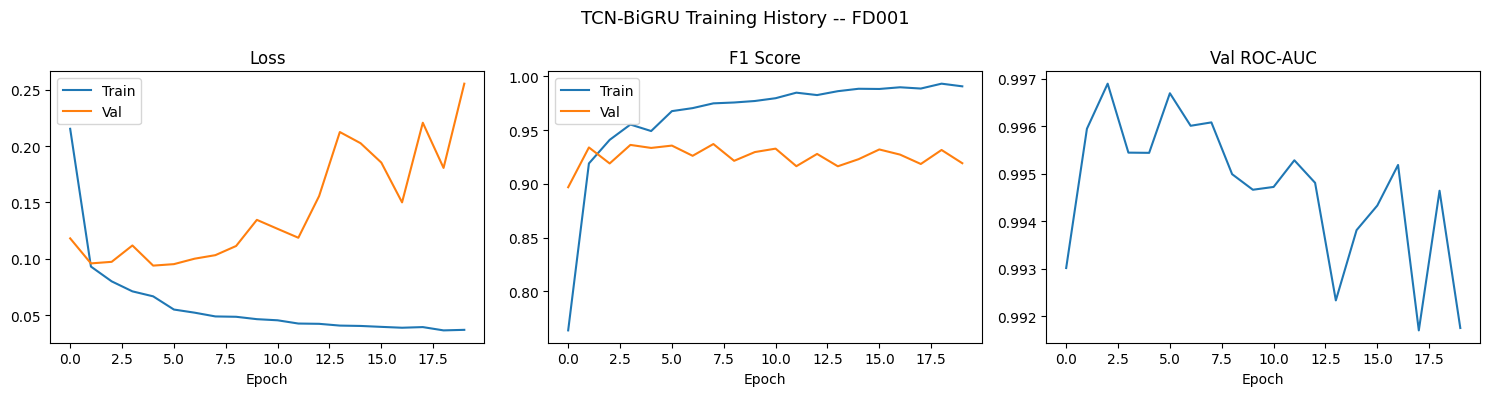

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['tr_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history['tr_f1'], label='Train')
axes[1].plot(history['val_f1'], label='Val')
axes[1].set_title('F1 Score'); axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(history['val_auc'])
axes[2].set_title('Val ROC-AUC'); axes[2].set_xlabel('Epoch')

plt.suptitle(f'TCN-BiGRU Training History -- {FD}', fontsize=13)
plt.tight_layout()
plt.show()

## Embedding Extraction (for XGBoost)

In [60]:
@torch.no_grad()
def extract_embeddings(X_np, batch_size=512):
    """Convert raw window array to embedding array via the trained TCN-BiGRU."""
    model.eval()
    embs = []
    for (xb,) in DataLoader(TensorDataset(torch.from_numpy(X_np)),
                             batch_size=batch_size, shuffle=False):
        embs.append(model.embed(xb.to(DEVICE)).detach().cpu().numpy())
    return np.vstack(embs)


def extract_semantic_features(X):
    """12 trend statistics per channel, fully vectorised across windows.
    Input  shape: (N, T, C)
    Output shape: (N, C * 12)
    """
    N, T, C = X.shape
    t       = np.arange(T, dtype=np.float32)
    t_mean  = t.mean()
    denom   = max(float(np.sum((t - t_mean) ** 2)), 1e-9)

    x_mean  = X.mean(axis=1)                                    # (N, C)
    x_std   = X.std(axis=1)
    x_min   = X.min(axis=1)
    x_max   = X.max(axis=1)
    x_rng   = x_max - x_min
    x_drift = X[:, -1, :] - X[:, 0, :]
    slope   = ((t[None, :, None] - t_mean) *
               (X - x_mean[:, None, :])).sum(axis=1) / denom    # (N, C)

    diff          = np.diff(X, axis=1)                          # (N, T-1, C)
    diff_abs_mean = np.abs(diff).mean(axis=1)
    diff_std      = diff.std(axis=1)
    energy        = (X ** 2).sum(axis=1) / T
    pos_frac      = (diff > 0).mean(axis=1)
    neg_frac      = (diff < 0).mean(axis=1)

    feats = np.stack([x_mean, x_std, x_min, x_max, x_rng, x_drift,
                      slope, diff_abs_mean, diff_std, energy,
                      pos_frac, neg_frac], axis=2)              # (N, C, 12)
    return feats.reshape(N, C * 12).astype(np.float32)


def fuse_features(emb, X):
    if not CFG['use_semantic_features']:
        return emb
    sem = extract_semantic_features(X)
    return np.concatenate([emb, sem], axis=1)


print('Extracting embeddings...')
emb_tr  = extract_embeddings(X_tr)
emb_val = extract_embeddings(X_val)
emb_te_last = extract_embeddings(X_te_last)
emb_te_sl   = extract_embeddings(X_te_sl)
print(f'emb_tr: {emb_tr.shape}  emb_val: {emb_val.shape}  '
      f'emb_last: {emb_te_last.shape}  emb_sliding: {emb_te_sl.shape}')

if CFG['use_semantic_features']:
    print('Extracting semantic trend features and fusing...')
else:
    print('Semantic trend features disabled; using deep embeddings only.')

feat_tr      = fuse_features(emb_tr, X_tr)
feat_val     = fuse_features(emb_val, X_val)
feat_te_last = fuse_features(emb_te_last, X_te_last)
feat_te_sl   = fuse_features(emb_te_sl, X_te_sl)

TEST_FEATURES = {
    'last': feat_te_last,
    'sliding': feat_te_sl,
}

print(f'fused_tr: {feat_tr.shape}  fused_val: {feat_val.shape}  '
      f'fused_last: {feat_te_last.shape}  fused_sliding: {feat_te_sl.shape}')

Extracting embeddings...
emb_tr: (13660, 128)  emb_val: (2477, 128)  emb_last: (100, 128)  emb_sliding: (9211, 128)
Extracting semantic trend features and fusing...
fused_tr: (13660, 332)  fused_val: (2477, 332)  fused_last: (100, 332)  fused_sliding: (9211, 332)


## XGBoost Hyperparameter Search (GridSearchCV, leakage-free)

Grid search over key XGBoost parameters using stratified k-fold CV scored on F-beta (β=2). **Trained on TRAIN ONLY** — validation set is reserved for threshold + engine-smoothing selection to avoid leakage.

In [61]:
# GridSearchCV on TRAIN ONLY (no val leakage). Val is reserved for threshold + engine smoothing.
scale_pos     = float((y_tr == 0).sum() / (y_tr == 1).sum())
scale_pos_bst = scale_pos * CFG['pos_weight_boost']
BETA          = CFG['recall_beta']

# F-beta scorer: beta>1 weights recall more than precision
f_beta_scorer = make_scorer(fbeta_score, beta=BETA, zero_division=0)

# Parameter grid (slightly trimmed for runtime; still covers the important axes)
param_grid = {
    'max_depth'        : [4, 6, 8],
    'learning_rate'    : [0.03, 0.05, 0.1],
    'min_child_weight' : [1, 3, 5],
    'subsample'        : [0.8, 1.0],
    'colsample_bytree' : [0.8, 1.0],
    'reg_alpha'        : [0.0, 0.1],
    'reg_lambda'       : [1.0, 2.0],
}

xgb_base = XGBClassifier(
    objective        = 'binary:logistic',
    n_estimators     = 400,
    scale_pos_weight = scale_pos_bst,
    tree_method      = 'hist',
    eval_metric      = 'logloss',
    random_state     = 42,
    verbosity        = 0,
)

cv_strategy = StratifiedKFold(
    n_splits=CFG['grid_cv_folds'], shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator  = xgb_base,
    param_grid = param_grid,
    scoring    = f_beta_scorer,
    cv         = cv_strategy,
    n_jobs     = CFG['grid_n_jobs'],
    verbose    = 1,
    refit      = True,
)

print(f'GridSearchCV on TRAIN ONLY ({CFG["grid_cv_folds"]}-fold CV, scoring=F{BETA:.0f}, '
      f'scale_pos_weight={scale_pos_bst:.2f})...')
grid_search.fit(feat_tr, y_tr)

best_params = grid_search.best_params_
best_cv_fb  = grid_search.best_score_

print('\n' + '=' * 58)
print(f'  Best CV F{BETA:.0f}  : {best_cv_fb:.4f}')
print(f'  Best parameters:')
for k, v in best_params.items():
    print(f'    {k:<22}: {v}')
print('=' * 58)

cv_df = pd.DataFrame(grid_search.cv_results_)
top10 = (
    cv_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
    .sort_values('rank_test_score').head(10).reset_index(drop=True)
)
top10.index += 1
top10.columns = ['Parameters', f'Mean F{BETA:.0f}', f'Std F{BETA:.0f}', 'Rank']
top10.iloc[:, 1] = top10.iloc[:, 1].round(4)
top10.iloc[:, 2] = top10.iloc[:, 2].round(4)
print(f'\nTop-10 configurations:')
print(top10.to_string())

GridSearchCV on TRAIN ONLY (3-fold CV, scoring=F2, scale_pos_weight=11.67)...
Fitting 3 folds for each of 432 candidates, totalling 1296 fits

  Best CV F2  : 0.9928
  Best parameters:
    colsample_bytree      : 1.0
    learning_rate         : 0.05
    max_depth             : 6
    min_child_weight      : 1
    reg_alpha             : 0.0
    reg_lambda            : 2.0
    subsample             : 1.0

Top-10 configurations:
                                                                                                                                        Parameters  Mean F2  Std F2  Rank
1   {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 6, 'min_child_weight': 1, 'reg_alpha': 0.0, 'reg_lambda': 2.0, 'subsample': 1.0}   0.9928  0.0027     1
2   {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 8, 'min_child_weight': 1, 'reg_alpha': 0.1, 'reg_lambda': 2.0, 'subsample': 0.8}   0.9927  0.0029     2
3   {'colsample_bytree': 1.0, 'learning_rate': 0.03, 'max_de

## XGBoost Final Training (Best Hyperparameters)

In [62]:
# Final XGBoost: train on TRAIN ONLY (fused features), use VAL as eval for early stopping.
# Both test protocol DMatrices are built here; neither is used for tuning.
dtrain = xgb.DMatrix(feat_tr,  label=y_tr)
dval   = xgb.DMatrix(feat_val, label=y_val)
dtest_last = xgb.DMatrix(feat_te_last, label=y_te_last)
dtest_sl   = xgb.DMatrix(feat_te_sl,   label=y_te_sl)

DTEST = {
    'last': dtest_last,
    'sliding': dtest_sl,
}

xgb_params = {
    'objective'        : 'binary:logistic',
    'eval_metric'      : ['logloss', 'auc'],
    'eta'              : best_params.get('learning_rate',    CFG['xgb_lr']),
    'max_depth'        : best_params.get('max_depth',        CFG['xgb_depth']),
    'subsample'        : best_params.get('subsample',        CFG['xgb_subsample']),
    'colsample_bytree' : best_params.get('colsample_bytree', CFG['xgb_colsample']),
    'min_child_weight' : best_params.get('min_child_weight', CFG['xgb_min_child']),
    'reg_alpha'        : best_params.get('reg_alpha',        CFG['xgb_alpha']),
    'reg_lambda'       : best_params.get('reg_lambda',       CFG['xgb_lambda']),
    'scale_pos_weight' : scale_pos_bst,
    'tree_method'      : 'hist',
    'seed'             : 42,
}

evals_result = {}
xgb_model = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round       = CFG['xgb_rounds'],
    evals                 = [(dtrain, 'train'), (dval, 'val')],
    early_stopping_rounds = CFG['xgb_es_rounds'],
    evals_result          = evals_result,
    verbose_eval          = 50,
)
print(f'\nBest boosting round: {xgb_model.best_iteration}')

[0]	train-logloss:0.89957	train-auc:0.99832	val-logloss:0.88120	val-auc:0.97421
[50]	train-logloss:0.05292	train-auc:1.00000	val-logloss:0.11253	val-auc:0.98229
[100]	train-logloss:0.00592	train-auc:1.00000	val-logloss:0.09670	val-auc:0.98244
[150]	train-logloss:0.00133	train-auc:1.00000	val-logloss:0.11267	val-auc:0.99590
[193]	train-logloss:0.00064	train-auc:1.00000	val-logloss:0.12392	val-auc:0.99575

Best boosting round: 153


## Threshold + Decision-Mode Selection (Validation Only)

Two decision modes are searched on validation:

1. **Window-level threshold**: max F1 with `min_precision` floor; tie-break by higher recall, lower threshold.
2. **Engine-level smoothing**: joint search over threshold, moving-average window, and persistence rule per engine.

The selected mode is frozen from validation and then applied to test. Test metrics are never used to choose between window and engine decisions.

In [63]:
from sklearn.metrics import precision_recall_fscore_support

# ===== Window-level threshold + engine-level smoothing helpers =====

def specificity_from_preds(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp + 1e-9)


def metric_dict(y_true, y_score, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0)
    return {
        'Precision': float(p),
        'Recall': float(r),
        'F1': float(f1),
        'Specificity': float(specificity_from_preds(y_true, y_pred)),
        'AUC': float(roc_auc_score(y_true, y_score)) if len(np.unique(y_true)) > 1 else float('nan'),
        'Avg Prec': float(average_precision_score(y_true, y_score)) if len(np.unique(y_true)) > 1 else float('nan'),
    }


def evaluate_threshold(y_true, y_score, threshold):
    y_hat = (y_score >= threshold).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_hat, average='binary', zero_division=0)
    return p, r, f1, y_hat


def moving_average(x, k=5):
    return pd.Series(x).rolling(window=k, min_periods=1).mean().values


def persistence_decision(probs, threshold, window, min_count):
    raw = (probs >= threshold).astype(int)
    out = np.zeros_like(raw)
    for i in range(len(raw)):
        start = max(0, i - window + 1)
        if raw[start:i+1].sum() >= min_count:
            out[i] = 1
    return out


def evaluate_engine_smoothed(y_true, probs, engine_ids, threshold, ma_k, persist_w, min_count):
    final = np.zeros_like(y_true)
    for eng in np.unique(engine_ids):
        idx = np.where(engine_ids == eng)[0]
        smoothed = moving_average(probs[idx], k=ma_k)
        final[idx] = persistence_decision(smoothed, threshold, persist_w, min_count)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, final, average='binary', zero_division=0)
    return p, r, f1, final


def choose_window_threshold(y_true, y_prob, min_prec, f1_tol):
    """Max F1 over thresholds with precision floor; tie-break by higher recall, lower thr."""
    cands = []
    for th in np.arange(0.05, 0.95, 0.0025):
        p, r, f1, _ = evaluate_threshold(y_true, y_prob, float(th))
        cands.append((float(th), p, r, f1))
    valid = [c for c in cands if c[1] >= min_prec]
    if not valid:
        valid = cands
    best_f1 = max(c[3] for c in valid)
    near = [c for c in valid if c[3] >= best_f1 - f1_tol]
    return sorted(near, key=lambda c: (-c[3], -c[2], c[0]))[0]


def choose_engine_setting(y_true, y_prob, eng_ids, min_prec, f1_tol, cfg):
    """Joint search over threshold, MA window, persistence (window, min_count)."""
    cands = []
    for ma_k in cfg['ma_k_grid']:
        for pw, mc in cfg['persist_grid']:
            for th in np.arange(0.10, 0.80, 0.01):
                p, r, f1, _ = evaluate_engine_smoothed(
                    y_true, y_prob, eng_ids, float(th), ma_k, pw, mc)
                cands.append((float(th), ma_k, pw, mc, p, r, f1))
    valid = [c for c in cands if c[4] >= min_prec]
    if not valid:
        valid = cands
    best_f1 = max(c[6] for c in valid)
    near = [c for c in valid if c[6] >= best_f1 - f1_tol]
    return sorted(near, key=lambda c: (-c[6], -c[5], c[0]))[0]


# ===== Run threshold and decision-mode selection on VAL only =====
val_probs = xgb_model.predict(dval)

best_th, best_p, best_r, best_f1 = choose_window_threshold(
    y_val, val_probs,
    min_prec=CFG['min_precision'],
    f1_tol=CFG['f1_tolerance'])

val_window_result = {
    'mode': 'window',
    'threshold': best_th,
    'precision': best_p,
    'recall': best_r,
    'f1': best_f1,
}
print(f'Window-level VAL pick :  thr={best_th:.4f}  P={best_p:.4f}  R={best_r:.4f}  F1={best_f1:.4f}')

eng_setting = None
val_engine_result = None
if CFG['use_engine_smoothing']:
    eng_setting = choose_engine_setting(
        y_val, val_probs, eng_val,
        min_prec=CFG['min_precision'],
        f1_tol=CFG['f1_tolerance'],
        cfg=CFG)
    eng_th, eng_ma, eng_pw, eng_mc, eng_p_v, eng_r_v, eng_f1_v = eng_setting
    val_engine_result = {
        'mode': 'engine',
        'threshold': eng_th,
        'ma_k': eng_ma,
        'persist_w': eng_pw,
        'min_count': eng_mc,
        'precision': eng_p_v,
        'recall': eng_r_v,
        'f1': eng_f1_v,
    }
    print(f'Engine-level VAL pick :  thr={eng_th:.2f}  ma_k={eng_ma}  '
          f'persist=({eng_pw},{eng_mc})  P={eng_p_v:.4f}  R={eng_r_v:.4f}  F1={eng_f1_v:.4f}')

mode_candidates = [val_window_result]
if val_engine_result is not None:
    mode_candidates.append(val_engine_result)

selected_val_decision = sorted(
    mode_candidates,
    key=lambda c: (-c['f1'], -c['recall'], 0 if c['mode'] == 'window' else 1)
)[0]
selected_decision_mode = selected_val_decision['mode']

print(f'>> Decision mode frozen from VAL: {selected_decision_mode.upper()} '
      f'(VAL F1={selected_val_decision["f1"]:.4f}, '
      f'P={selected_val_decision["precision"]:.4f}, R={selected_val_decision["recall"]:.4f})')

Window-level VAL pick :  thr=0.8900  P=0.9560  R=0.9178  F1=0.9365
Engine-level VAL pick :  thr=0.13  ma_k=7  persist=(2,1)  P=0.9316  R=0.9378  F1=0.9347
>> Decision mode frozen from VAL: WINDOW (VAL F1=0.9365, P=0.9560, R=0.9178)


## Dual-Protocol Test Evaluation

Both test protocols are evaluated every run. The `last` protocol is the CMAPSS literature-comparable result; the `sliding` protocol is the full-timeline operational result. For sliding, the window-vs-engine decision mode is the one selected on validation in the previous cell.

In [64]:
def evaluate_test_protocol(protocol, y_true, probs, engine_ids, allow_engine):
    """Evaluate one test protocol without using test metrics for model selection."""
    rows = []

    _, _, _, pred_win = evaluate_threshold(y_true, probs, best_th)
    win_metrics = metric_dict(y_true, probs, pred_win)
    win_selected = (not allow_engine) or selected_decision_mode == 'window'
    rows.append({
        'Protocol': protocol,
        'Decision': 'window',
        'Selected by VAL': win_selected,
        'Threshold': f'{best_th:.4f}',
        'Precision': win_metrics['Precision'],
        'Recall': win_metrics['Recall'],
        'F1': win_metrics['F1'],
        'Specificity': win_metrics['Specificity'],
        'AUC': win_metrics['AUC'],
        'Avg Prec': win_metrics['Avg Prec'],
        'N': int(len(y_true)),
        'Positive Rate': float(np.mean(y_true)),
    })

    selected_pred = pred_win
    selected_metrics = win_metrics
    selected_thr = best_th
    selected_mode = 'window'

    if allow_engine and eng_setting is not None:
        eng_th, eng_ma, eng_pw, eng_mc, *_ = eng_setting
        _, _, _, pred_eng = evaluate_engine_smoothed(
            y_true, probs, engine_ids, eng_th, eng_ma, eng_pw, eng_mc)
        eng_metrics = metric_dict(y_true, probs, pred_eng)
        eng_selected = selected_decision_mode == 'engine'
        rows.append({
            'Protocol': protocol,
            'Decision': 'engine',
            'Selected by VAL': eng_selected,
            'Threshold': f'{eng_th:.4f}; ma={eng_ma}; persist=({eng_pw},{eng_mc})',
            'Precision': eng_metrics['Precision'],
            'Recall': eng_metrics['Recall'],
            'F1': eng_metrics['F1'],
            'Specificity': eng_metrics['Specificity'],
            'AUC': eng_metrics['AUC'],
            'Avg Prec': eng_metrics['Avg Prec'],
            'N': int(len(y_true)),
            'Positive Rate': float(np.mean(y_true)),
        })
        if eng_selected:
            selected_pred = pred_eng
            selected_metrics = eng_metrics
            selected_thr = eng_th
            selected_mode = 'engine'

    selected = {
        'protocol': protocol,
        'decision_mode': selected_mode,
        'threshold': selected_thr,
        'y_true': y_true,
        'probs': probs,
        'preds': selected_pred,
        **selected_metrics,
    }
    return selected, rows


test_probs_last = xgb_model.predict(dtest_last)
test_probs_sl   = xgb_model.predict(dtest_sl)

last_selected, last_rows = evaluate_test_protocol(
    'last', y_te_last, test_probs_last, eng_te_last, allow_engine=False)
sliding_selected, sliding_rows = evaluate_test_protocol(
    'sliding', y_te_sl, test_probs_sl, eng_te_sl,
    allow_engine=CFG['use_engine_smoothing'])

protocol_results = {
    'last': last_selected,
    'sliding': sliding_selected,
}

test_report_df = pd.DataFrame(last_rows + sliding_rows)
metric_display_cols = [
    'Protocol', 'Decision', 'Selected by VAL', 'Threshold', 'N', 'Positive Rate',
    'Precision', 'Recall', 'F1', 'Specificity', 'AUC', 'Avg Prec'
]
print('=' * 90)
print(f'  {FD} -- Dual-Protocol Test Report (selection frozen on validation)')
print('=' * 90)
print(test_report_df[metric_display_cols].round(4).to_string(index=False))
print('=' * 90)

try:
    from IPython.display import display
    display(test_report_df[metric_display_cols].round(4))
except Exception:
    pass

for protocol_name, selected in protocol_results.items():
    print('\n' + '-' * 70)
    print(f'{protocol_name.upper()} protocol | selected decision: {selected["decision_mode"]}')
    print(classification_report(
        selected['y_true'], selected['preds'],
        target_names=['Normal', 'Near Failure'], zero_division=0))

# Backward-compatible aliases for the dashboard and summary cells.
# This is a fixed reporting choice, not a test-performance choice.
primary_protocol = CFG.get('primary_test_protocol', 'last')
if primary_protocol not in protocol_results:
    primary_protocol = 'last'
primary_result = protocol_results[primary_protocol]

y_te       = primary_result['y_true']
test_probs = primary_result['probs']
test_preds = primary_result['preds']
best_thr   = primary_result['threshold']
precision  = primary_result['Precision']
recall     = primary_result['Recall']
f1         = primary_result['F1']
spec       = primary_result['Specificity']
auc        = primary_result['AUC']
ap         = primary_result['Avg Prec']
primary_decision_mode = primary_result['decision_mode']

cm = confusion_matrix(y_te, test_preds, labels=[0, 1])
tn, fp, fn, tp_count = cm.ravel()
print(f'\nDashboard primary protocol: {primary_protocol} / {primary_decision_mode}')
print(f'Final primary metrics: P={precision:.4f}  R={recall:.4f}  F1={f1:.4f}  Spec={spec:.4f}')

  FD001 -- Dual-Protocol Test Report (selection frozen on validation)
Protocol Decision  Selected by VAL                   Threshold    N  Positive Rate  Precision  Recall     F1  Specificity    AUC  Avg Prec
    last   window             True                      0.8900  100         0.2500     0.9500  0.7600 0.8444       0.9867 0.9925    0.9762
 sliding   window             True                      0.8900 9211         0.0333     0.8812  0.7492 0.8099       0.9965 0.9961    0.9085
 sliding   engine            False 0.1300; ma=7; persist=(2,1) 9211         0.0333     0.8321  0.7590 0.7939       0.9947 0.9961    0.9085


,Protocol,Decision,Selected by VAL,Threshold,N,Positive Rate,Precision,Recall,F1,Specificity,AUC,Avg Prec
0,last,window,True,0.8900,100,0.2500,0.9500,0.7600,0.8444,0.9867,0.9925,0.9762
1,sliding,window,True,0.8900,9211,0.0333,0.8812,0.7492,0.8099,0.9965,0.9961,0.9085
2,sliding,engine,False,"0.1300; ma=7; persist=(2,1)",9211,0.0333,0.8321,0.7590,0.7939,0.9947,0.9961,0.9085



----------------------------------------------------------------------
LAST protocol | selected decision: window
              precision    recall  f1-score   support

      Normal       0.93      0.99      0.95        75
Near Failure       0.95      0.76      0.84        25

    accuracy                           0.93       100
   macro avg       0.94      0.87      0.90       100
weighted avg       0.93      0.93      0.93       100


----------------------------------------------------------------------
SLIDING protocol | selected decision: window
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99      8904
Near Failure       0.88      0.75      0.81       307

    accuracy                           0.99      9211
   macro avg       0.94      0.87      0.90      9211
weighted avg       0.99      0.99      0.99      9211


Dashboard primary protocol: last / window
Final primary metrics: P=0.9500  R=0.7600  F1=0.8444  Spec=0.9867


## Results Dashboard

Six-panel dashboard: confusion matrix, ROC curve, PR curve, score distribution, XGBoost feature importance, and metrics bar chart.

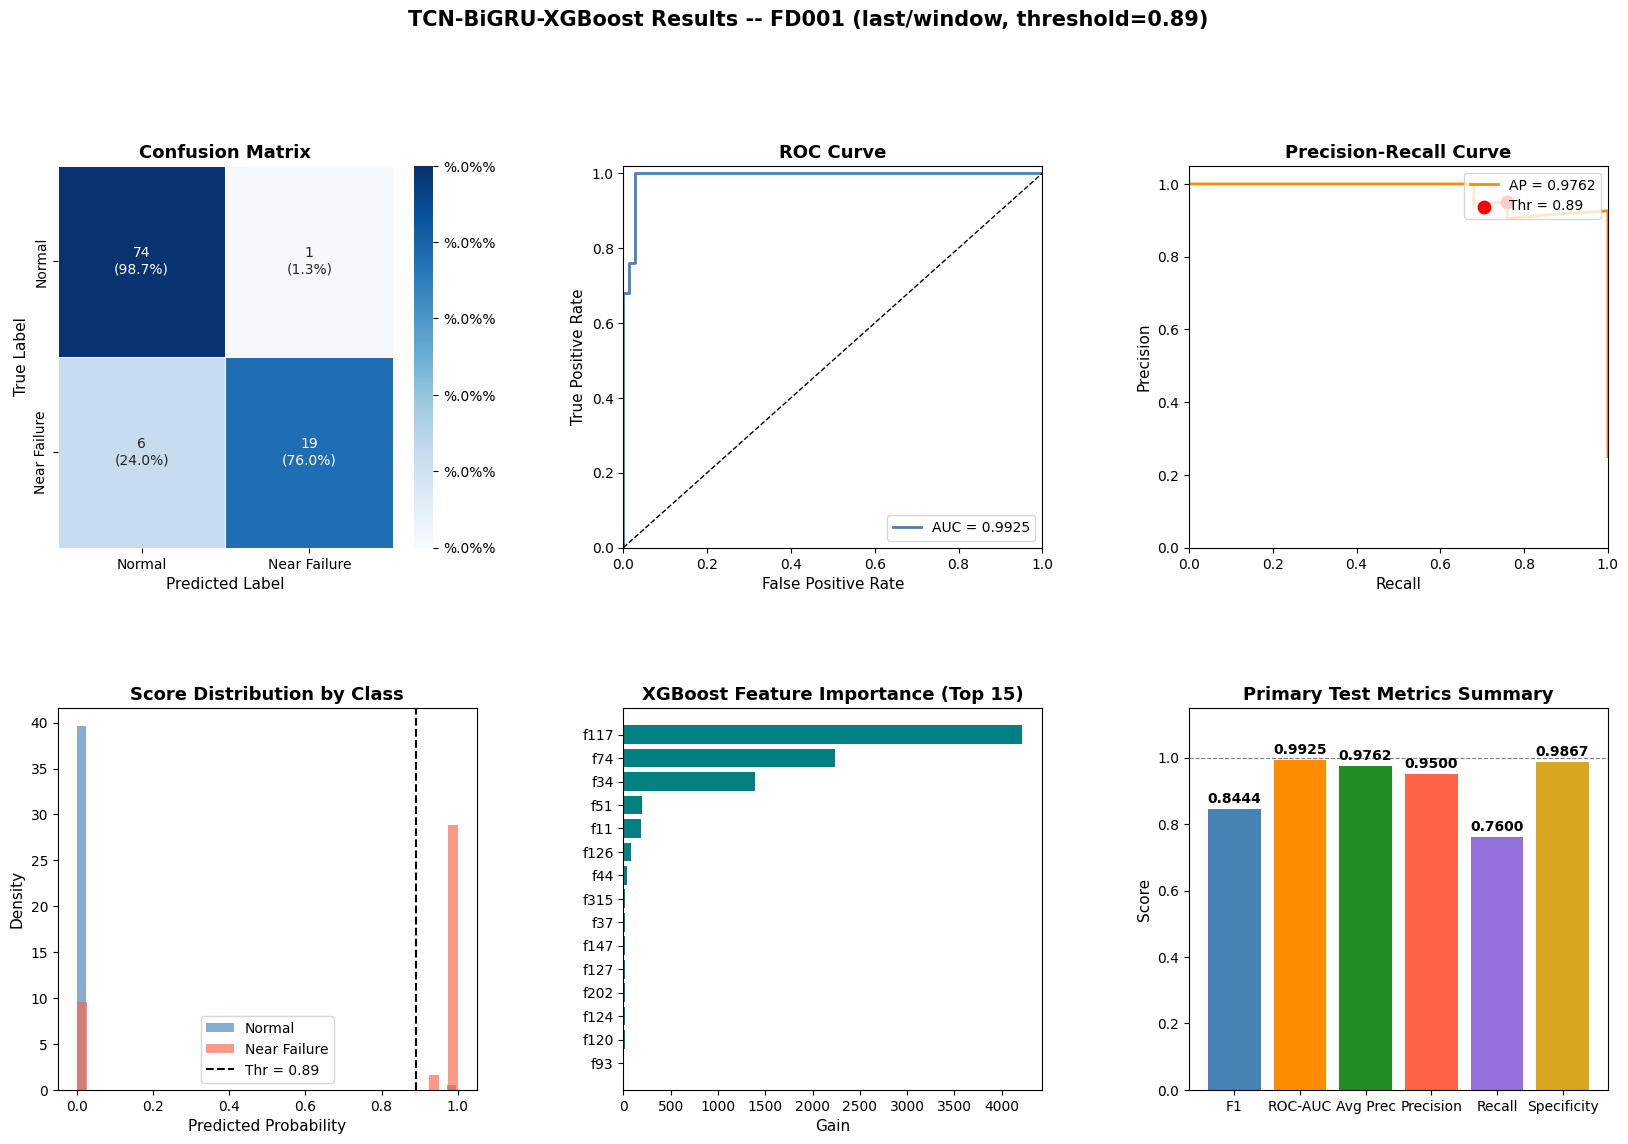

Dashboard saved: results_dashboard_FD001_last_window.png


In [65]:
def plot_confusion(ax, y_true, y_pred, classes=('Normal', 'Near Failure')):
    cm_raw  = confusion_matrix(y_true, y_pred, labels=[0, 1])
    row_sum = cm_raw.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm_raw.astype(float), row_sum, out=np.zeros_like(cm_raw, dtype=float), where=row_sum != 0)
    annot   = [[f'{v}\n({p:.1%})' for v, p in zip(rv, rp)]
                for rv, rp in zip(cm_raw, cm_norm)]
    sns.heatmap(cm_norm, annot=annot, fmt='', cmap='Blues', ax=ax,
                xticklabels=classes, yticklabels=classes,
                vmin=0, vmax=1, linewidths=0.5, cbar_kws={'format': '%.0%%'})
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_title('Confusion Matrix', fontsize=13, fontweight='bold')


def plot_roc(ax, y_true, y_score):
    if len(np.unique(y_true)) < 2:
        ax.text(0.5, 0.5, 'ROC unavailable: one class only', ha='center', va='center')
        ax.set_axis_off()
        return
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc_v = roc_auc_score(y_true, y_score)
    ax.plot(fpr, tpr, lw=2, color='steelblue', label=f'AUC = {auc_v:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title('ROC Curve', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])


def plot_pr(ax, y_true, y_score, threshold):
    if len(np.unique(y_true)) < 2:
        ax.text(0.5, 0.5, 'PR unavailable: one class only', ha='center', va='center')
        ax.set_axis_off()
        return
    prec, rec, thrs = precision_recall_curve(y_true, y_score)
    ap_v = average_precision_score(y_true, y_score)
    ax.plot(rec, prec, lw=2, color='darkorange', label=f'AP = {ap_v:.4f}')
    if len(thrs) > 0:
        idx = np.argmin(np.abs(thrs - threshold))
        ax.scatter(rec[idx], prec[idx], color='red', zorder=5, s=80,
                   label=f'Thr = {threshold:.2f}')
    ax.set_xlabel('Recall', fontsize=11)
    ax.set_ylabel('Precision', fontsize=11)
    ax.set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
    ax.legend(loc='upper right')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])


def plot_score_dist(ax, y_true, y_score, threshold):
    for label, color, name in [(0, 'steelblue', 'Normal'),
                                (1, 'tomato', 'Near Failure')]:
        vals = y_score[y_true == label]
        if len(vals) > 0:
            ax.hist(vals, bins=40, alpha=0.65,
                    color=color, label=name, density=True)
    ax.axvline(threshold, color='black', linestyle='--', lw=1.5,
               label=f'Thr = {threshold:.2f}')
    ax.set_xlabel('Predicted Probability', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title('Score Distribution by Class', fontsize=13, fontweight='bold')
    ax.legend()


def plot_feat_importance(ax, model, top_n=15):
    scores = model.get_score(importance_type='gain')
    if not scores:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center'); return
    s_sorted = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    feats, vals = zip(*s_sorted)
    ax.barh(feats[::-1], vals[::-1], color='teal')
    ax.set_xlabel('Gain', fontsize=11)
    ax.set_title(f'XGBoost Feature Importance (Top {top_n})',
                 fontsize=13, fontweight='bold')


def plot_metrics_bar(ax, metrics_dict):
    names  = list(metrics_dict.keys())
    values = list(metrics_dict.values())
    colors = ['steelblue', 'darkorange', 'forestgreen',
              'tomato', 'mediumpurple', 'goldenrod']
    bars   = ax.bar(names, values, color=colors[:len(names)])
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title('Primary Test Metrics Summary', fontsize=13, fontweight='bold')
    ax.axhline(1.0, color='gray', linestyle='--', lw=0.8)


metrics_dict = {
    'F1'         : f1,
    'ROC-AUC'    : auc,
    'Avg Prec'   : ap,
    'Precision'  : precision,
    'Recall'     : recall,
    'Specificity': spec,
}

fig = plt.figure(figsize=(20, 12))
fig.suptitle(f'TCN-BiGRU-XGBoost Results -- {FD} ({primary_protocol}/{primary_decision_mode}, threshold={best_thr:.2f})',
             fontsize=15, fontweight='bold', y=1.01)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])

plot_confusion(ax1, y_te, test_preds)
plot_roc(ax2, y_te, test_probs)
plot_pr(ax3, y_te, test_probs, best_thr)
plot_score_dist(ax4, y_te, test_probs, best_thr)
plot_feat_importance(ax5, xgb_model)
plot_metrics_bar(ax6, metrics_dict)

plt.savefig(f'results_dashboard_{FD}_{primary_protocol}_{primary_decision_mode}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Dashboard saved: results_dashboard_{FD}_{primary_protocol}_{primary_decision_mode}.png')

## Metrics Summary Table

In [66]:
report_dict = classification_report(
    y_te, test_preds, target_names=['Normal', 'Near Failure'], output_dict=True,
    zero_division=0)

rows = []
for cls in ['Normal', 'Near Failure']:
    rows.append({
        'Class'    : cls,
        'Precision': round(report_dict[cls]['precision'], 4),
        'Recall'   : round(report_dict[cls]['recall'],    4),
        'F1-Score' : round(report_dict[cls]['f1-score'],  4),
        'Support'  : int(report_dict[cls]['support']),
    })
for name, val in [('Overall F1', f1), ('ROC-AUC', auc),
                  ('Avg Precision', ap), ('Specificity', spec)]:
    rows.append({'Class': name, 'Precision': round(val, 4),
                 'Recall': '--', 'F1-Score': '--', 'Support': '--'})

df_summary = pd.DataFrame(rows).set_index('Class')

print('\n' + '=' * 72)
print(f'  {FD} -- TCN-BiGRU + XGBoost ({primary_protocol}/{primary_decision_mode})')
print('=' * 72)
print(df_summary.to_string())
print('=' * 72)

try:
    from IPython.display import display
    styled = (
        df_summary.style
        .set_caption(f'TCN-BiGRU-XGBoost Results -- {FD} ({primary_protocol}/{primary_decision_mode})')
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-size', '14px'), ('font-weight', 'bold')]},
            {'selector': 'th',
             'props': [('background-color', '#4472C4'), ('color', 'white'),
                       ('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td',
             'props': [('text-align', 'center'), ('padding', '6px 12px')]},
        ])
    )
    display(styled)
except Exception:
    pass


  FD001 -- TCN-BiGRU + XGBoost (last/window)
               Precision  Recall F1-Score Support
Class                                            
Normal            0.9250  0.9867   0.9548      75
Near Failure      0.9500    0.76   0.8444      25
Overall F1        0.8444      --       --      --
ROC-AUC           0.9925      --       --      --
Avg Precision     0.9762      --       --      --
Specificity       0.9867      --       --      --


,Precision,Recall,F1-Score,Support
Class,,,,
Normal,0.925000,0.986700,0.954800,75
Near Failure,0.950000,0.760000,0.844400,25
Overall F1,0.844400,--,--,--
ROC-AUC,0.992500,--,--,--
Avg Precision,0.976200,--,--,--
Specificity,0.986700,--,--,--


## Full FD001-FD004 Batch Evaluation (Dual Protocol)

End-to-end run across all four datasets with the upgraded pipeline. Each dataset reports both `last` and `sliding` test protocols. Thresholds and the sliding window-vs-engine decision mode are selected on validation only; test metrics are never used to choose the reported decision mode.

In [67]:
def selected_protocol_result(protocol, y_true, probs, engine_ids, win_thr, selected_mode,
                             engine_setting=None, allow_engine=False):
    """Return selected metrics plus per-mode diagnostics for one protocol."""
    _, _, _, pred_win = evaluate_threshold(y_true, probs, win_thr)
    win_metrics = metric_dict(y_true, probs, pred_win)

    result = {
        'selected_mode': 'window',
        'selected_pred': pred_win,
        'selected_metrics': win_metrics,
        'window_metrics': win_metrics,
        'engine_metrics': None,
        'engine_setting': None,
    }

    if allow_engine and engine_setting is not None:
        e_th, e_ma, e_pw, e_mc, *_ = engine_setting
        _, _, _, pred_eng = evaluate_engine_smoothed(
            y_true, probs, engine_ids, e_th, e_ma, e_pw, e_mc)
        eng_metrics = metric_dict(y_true, probs, pred_eng)
        result['engine_metrics'] = eng_metrics
        result['engine_setting'] = f'thr={e_th:.2f},ma_k={e_ma},persist=({e_pw},{e_mc})'
        if selected_mode == 'engine':
            result['selected_mode'] = 'engine'
            result['selected_pred'] = pred_eng
            result['selected_metrics'] = eng_metrics
    return result


def run_full_pipeline(fd, cfg=CFG, seed=42):
    """End-to-end dual-protocol run.

    TCN+BiGRU is trained on train, XGBoost grid search is train-only, validation
    selects threshold and decision mode, and both test protocols are reported.
    """
    seed_everything(seed)

    # ---- Data ----
    train_r, test_r, rul_r = load_raw(fd)
    train_r = add_train_rul(train_r)
    test_r  = add_test_rul(test_r, rul_r)
    tr, va  = split_train_val(train_r, cfg['val_engine_frac'], seed=seed)
    fc      = get_features(tr)

    if cfg.get('remove_outliers', True):
        out_cols, out_lower, out_upper = fit_outlier_bounds(
            tr, fc, iqr_k=cfg.get('outlier_iqr_k', 3.0))
        before_rows = len(tr)
        tr, out_removed, out_frac = remove_train_outliers(
            tr, out_cols, out_lower, out_upper, min_hits=cfg.get('outlier_min_hits', 2))
        va = clip_to_outlier_bounds(va, out_cols, out_lower, out_upper)
        test_r = clip_to_outlier_bounds(test_r, out_cols, out_lower, out_upper)
        print(f'Outlier removal ({fd}): dropped {out_removed}/{before_rows} train rows '
              f'({out_frac:.2%}); clipped val/test to train bounds')

    sc = StandardScaler()
    tr[fc]     = sc.fit_transform(tr[fc])
    va[fc]     = sc.transform(va[fc])
    test_r[fc] = sc.transform(test_r[fc])

    SL, ST, TH = cfg['seq_len'], cfg['stride'], cfg['rul_threshold']
    Xtr, ytr, _      = make_sliding_windows(tr, fc, SL, ST, TH)
    Xva, yva, eng_va = make_sliding_windows(va, fc, SL, ST, TH)
    Xlast, ylast, eng_last = make_test_windows_last(test_r, rul_r, fc, SL, TH)
    Xsl,   ysl,   eng_sl   = make_sliding_windows(test_r, fc, SL, ST, TH)

    # ---- Train TCN+BiGRU with hybrid loss ----
    m  = TCNBiGRU(Xtr.shape[2], cfg).to(DEVICE)
    raw_pr = float((ytr == 0).sum() / (ytr == 1).sum())
    pw = torch.tensor([raw_pr * cfg['pos_weight_boost']], dtype=torch.float32).to(DEVICE)
    crit_cls   = FocalLoss(gamma=cfg['focal_gamma'], pos_weight=pw)
    crit_recon = nn.MSELoss()
    Rw = cfg['recon_weight']

    opt = torch.optim.AdamW(m.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg['epochs'], eta_min=1e-5)
    trl = get_loader(Xtr, ytr, cfg['batch_size'])
    vll = get_loader(Xva, yva, cfg['batch_size'], shuffle=False)
    beta = cfg['recall_beta']

    best_fb, best_st, no_imp = -1.0, None, 0
    for ep in range(1, cfg['epochs'] + 1):
        m.train()
        for xb, yb in trl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits, recon, _ = m(xb)
            loss = crit_cls(logits, yb) + Rw * crit_recon(recon, xb[:, -1, :])
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()
        sch.step()
        m.eval(); vp_enc, vt = [], []
        with torch.no_grad():
            for xb, yb in vll:
                logits, _, _ = m(xb.to(DEVICE))
                vp_enc.extend(torch.sigmoid(logits).cpu().numpy())
                vt.extend(yb.numpy())
        vfb = fbeta_score(vt, (np.array(vp_enc) >= 0.5).astype(int), beta=beta, zero_division=0)
        if vfb > best_fb:
            best_fb = vfb
            best_st = {k: v.cpu().clone() for k, v in m.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
        if no_imp >= cfg['patience']:
            break
    m.load_state_dict(best_st)

    # ---- Embedding extraction ----
    @torch.no_grad()
    def _emb(X):
        m.eval(); parts = []
        for (xb,) in DataLoader(TensorDataset(torch.from_numpy(X)), batch_size=512):
            parts.append(m.embed(xb.to(DEVICE)).cpu().numpy())
        return np.vstack(parts)

    e_tr, e_va = _emb(Xtr), _emb(Xva)
    e_last, e_sl = _emb(Xlast), _emb(Xsl)

    if cfg['use_semantic_features']:
        f_tr    = np.concatenate([e_tr,   extract_semantic_features(Xtr)], axis=1)
        f_va    = np.concatenate([e_va,   extract_semantic_features(Xva)], axis=1)
        f_last  = np.concatenate([e_last, extract_semantic_features(Xlast)], axis=1)
        f_sl    = np.concatenate([e_sl,   extract_semantic_features(Xsl)], axis=1)
    else:
        f_tr, f_va, f_last, f_sl = e_tr, e_va, e_last, e_sl

    # ---- GridSearchCV on TRAIN ONLY ----
    sp     = float((ytr == 0).sum() / (ytr == 1).sum())
    sp_bst = sp * cfg['pos_weight_boost']
    f_beta = make_scorer(fbeta_score, beta=beta, zero_division=0)

    gs = GridSearchCV(
        XGBClassifier(objective='binary:logistic', n_estimators=400,
                      scale_pos_weight=sp_bst, tree_method='hist',
                      eval_metric='logloss', random_state=seed, verbosity=0),
        param_grid={
            'max_depth'        : [4, 6],
            'learning_rate'    : [0.03, 0.1],
            'min_child_weight' : [1, 3],
            'subsample'        : [0.8, 1.0],
            'colsample_bytree' : [0.8, 1.0],
        },
        scoring=f_beta,
        cv=StratifiedKFold(3, shuffle=True, random_state=seed),
        n_jobs=cfg['grid_n_jobs'], verbose=0,
    )
    gs.fit(f_tr, ytr)
    bp = gs.best_params_

    # ---- Final XGBoost (train only, val for early stopping) ----
    xm = xgb.train(
        {'objective': 'binary:logistic', 'eval_metric': ['logloss', 'auc'],
         'eta': bp['learning_rate'], 'max_depth': bp['max_depth'],
         'subsample': bp['subsample'], 'colsample_bytree': bp['colsample_bytree'],
         'min_child_weight': bp['min_child_weight'],
         'reg_alpha': cfg['xgb_alpha'], 'reg_lambda': cfg['xgb_lambda'],
         'scale_pos_weight': sp_bst, 'tree_method': 'hist', 'seed': seed},
        xgb.DMatrix(f_tr, label=ytr),
        num_boost_round=cfg['xgb_rounds'],
        evals=[(xgb.DMatrix(f_va, label=yva), 'val')],
        early_stopping_rounds=cfg['xgb_es_rounds'],
        verbose_eval=False,
    )

    # ---- Threshold + decision-mode selection on VAL ----
    vp = xm.predict(xgb.DMatrix(f_va))
    win_thr, win_p_v, win_r_v, win_f1_v = choose_window_threshold(
        yva, vp, min_prec=cfg['min_precision'], f1_tol=cfg['f1_tolerance'])

    engine_setting = None
    engine_val = None
    if cfg['use_engine_smoothing']:
        engine_setting = choose_engine_setting(
            yva, vp, eng_va,
            min_prec=cfg['min_precision'], f1_tol=cfg['f1_tolerance'], cfg=cfg)
        e_th, e_ma, e_pw, e_mc, e_p_v, e_r_v, e_f1_v = engine_setting
        engine_val = {'mode': 'engine', 'f1': e_f1_v, 'recall': e_r_v, 'precision': e_p_v}

    val_modes = [{'mode': 'window', 'f1': win_f1_v, 'recall': win_r_v, 'precision': win_p_v}]
    if engine_val is not None:
        val_modes.append(engine_val)
    selected_mode = sorted(
        val_modes,
        key=lambda c: (-c['f1'], -c['recall'], 0 if c['mode'] == 'window' else 1)
    )[0]['mode']

    # ---- Dual-protocol test reporting ----
    p_last = xm.predict(xgb.DMatrix(f_last))
    p_sl   = xm.predict(xgb.DMatrix(f_sl))

    last_res = selected_protocol_result(
        'last', ylast, p_last, eng_last, win_thr, selected_mode,
        engine_setting=None, allow_engine=False)
    sl_res = selected_protocol_result(
        'sliding', ysl, p_sl, eng_sl, win_thr, selected_mode,
        engine_setting=engine_setting, allow_engine=cfg['use_engine_smoothing'])

    out = {
        'Val Decision': selected_mode,
        'Val Window F1': float(win_f1_v),
        'Val Engine F1': float(engine_val['f1']) if engine_val is not None else float('nan'),
        'Last Decision': last_res['selected_mode'],
        'Last F1': float(last_res['selected_metrics']['F1']),
        'Last Precision': float(last_res['selected_metrics']['Precision']),
        'Last Recall': float(last_res['selected_metrics']['Recall']),
        'Last Specificity': float(last_res['selected_metrics']['Specificity']),
        'Last AUC': float(last_res['selected_metrics']['AUC']),
        'Last Avg Prec': float(last_res['selected_metrics']['Avg Prec']),
        'Sliding Decision': sl_res['selected_mode'],
        'Sliding F1': float(sl_res['selected_metrics']['F1']),
        'Sliding Precision': float(sl_res['selected_metrics']['Precision']),
        'Sliding Recall': float(sl_res['selected_metrics']['Recall']),
        'Sliding Specificity': float(sl_res['selected_metrics']['Specificity']),
        'Sliding AUC': float(sl_res['selected_metrics']['AUC']),
        'Sliding Avg Prec': float(sl_res['selected_metrics']['Avg Prec']),
        'Sliding Window F1': float(sl_res['window_metrics']['F1']),
        'Sliding Engine F1': float(sl_res['engine_metrics']['F1']) if sl_res['engine_metrics'] is not None else float('nan'),
        'Engine Setting': sl_res['engine_setting'],
        'Best Params': str(bp),
    }
    return out


print('Running all CMAPSS datasets with dual-protocol pipeline...')
all_results = {}
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    print(f'\n--- {fd} ---', flush=True)
    r = run_full_pipeline(fd, seed=42)
    all_results[fd] = r
    print(f"  last    [{r['Last Decision']}] F1={r['Last F1']:.4f}  "
          f"P={r['Last Precision']:.4f}  R={r['Last Recall']:.4f}  AUC={r['Last AUC']:.4f}")
    print(f"  sliding [{r['Sliding Decision']}] F1={r['Sliding F1']:.4f}  "
          f"P={r['Sliding Precision']:.4f}  R={r['Sliding Recall']:.4f}  AUC={r['Sliding AUC']:.4f}")
    print(f"  VAL decision={r['Val Decision']} | VAL window F1={r['Val Window F1']:.4f} | "
          f"VAL engine F1={r['Val Engine F1']:.4f}")

Running all CMAPSS datasets with dual-protocol pipeline...

--- FD001 ---
Outlier removal (FD001): dropped 594/17569 train rows (3.38%); clipped val/test to train bounds
  last    [window] F1=0.8444  P=0.9500  R=0.7600  AUC=0.9936
  sliding [window] F1=0.7848  P=0.8821  R=0.7068  AUC=0.9960
  VAL decision=window | VAL window F1=0.9478 | VAL engine F1=0.9468

--- FD002 ---
Outlier removal (FD002): dropped 897/45922 train rows (1.95%); clipped val/test to train bounds
  last    [window] F1=0.8819  P=0.8358  R=0.9333  AUC=0.9871
  sliding [engine] F1=0.6829  P=0.5935  R=0.8041  AUC=0.9790
  VAL decision=engine | VAL window F1=0.8344 | VAL engine F1=0.8389

--- FD003 ---
Outlier removal (FD003): dropped 1347/21075 train rows (6.39%); clipped val/test to train bounds
  last    [window] F1=0.9231  P=0.9474  R=0.9000  AUC=0.9969
  sliding [engine] F1=0.8725  P=0.8497  R=0.8967  AUC=0.9987
  VAL decision=engine | VAL window F1=0.9304 | VAL engine F1=0.9370

--- FD004 ---
Outlier removal (FD004

## Cross-Dataset Dual-Protocol Results Table

  TCN-BiGRU + XGBoost -- Cross-Dataset Dual-Protocol Results
      Val Decision Last Decision Sliding Decision  Last F1  Sliding F1  Last AUC  Sliding AUC  Last Precision  Sliding Precision  Last Recall  Sliding Recall  Sliding Window F1  Sliding Engine F1                 Engine Setting
FD001       window        window           window   0.8444      0.7848    0.9936       0.9960          0.9500             0.8821       0.7600          0.7068             0.7848             0.7778  thr=0.62,ma_k=3,persist=(2,1)
FD002       engine        window           engine   0.8819      0.6829    0.9871       0.9790          0.8358             0.5935       0.9333          0.8041             0.6874             0.6829  thr=0.10,ma_k=3,persist=(3,1)
FD003       engine        window           engine   0.9231      0.8725    0.9969       0.9987          0.9474             0.8497       0.9000          0.8967             0.8566             0.8725  thr=0.23,ma_k=7,persist=(2,1)
FD004       engine        windo

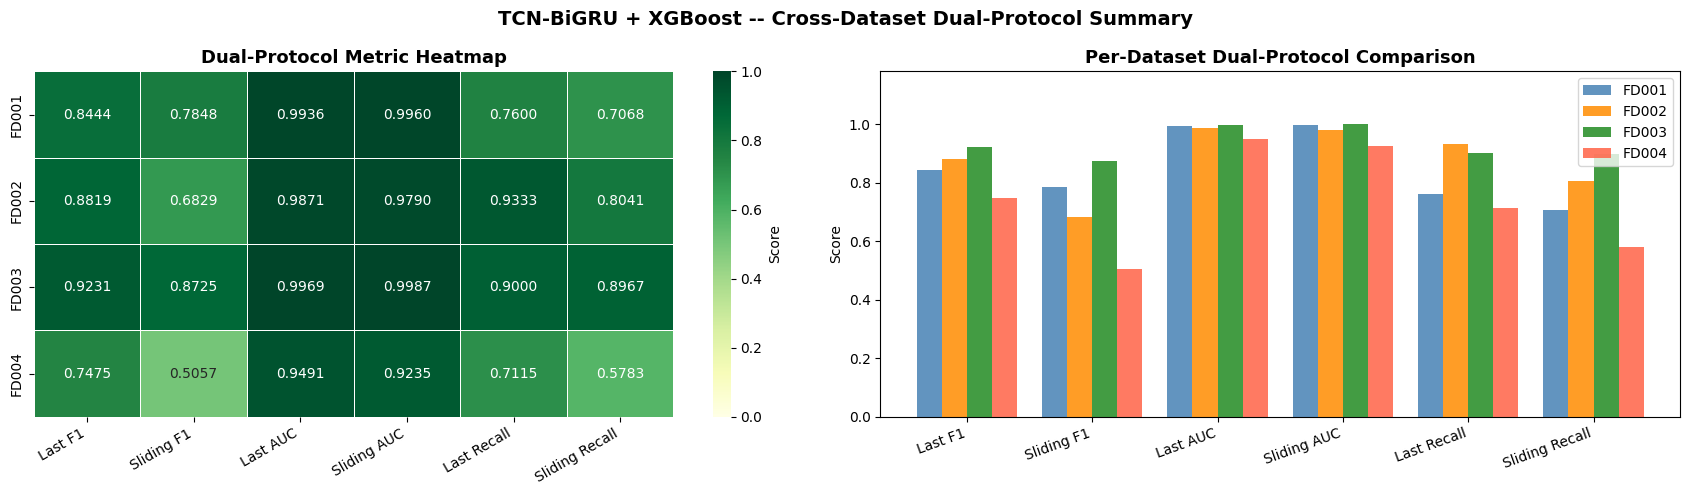

Saved: cross_dataset_dual_protocol_results.png


,Val Decision,Last Decision,Sliding Decision,Last F1,Sliding F1,Last AUC,Sliding AUC,Last Precision,Sliding Precision,Last Recall,Sliding Recall,Sliding Window F1,Sliding Engine F1,Engine Setting
FD001,window,window,window,0.844400,0.784800,0.993600,0.996000,0.950000,0.882100,0.760000,0.706800,0.784800,0.777800,"thr=0.62,ma_k=3,persist=(2,1)"
FD002,engine,window,engine,0.881900,0.682900,0.987100,0.979000,0.835800,0.593500,0.933300,0.804100,0.687400,0.682900,"thr=0.10,ma_k=3,persist=(3,1)"
FD003,engine,window,engine,0.923100,0.872500,0.996900,0.998700,0.947400,0.849700,0.900000,0.896700,0.856600,0.872500,"thr=0.23,ma_k=7,persist=(2,1)"
FD004,engine,window,engine,0.747500,0.505700,0.949100,0.923500,0.787200,0.449200,0.711500,0.578300,0.486300,0.505700,"thr=0.12,ma_k=7,persist=(3,1)"


In [68]:
result_rows = pd.DataFrame(all_results).T
numeric_cols = [
    'Val Window F1', 'Val Engine F1',
    'Last F1', 'Last AUC', 'Last Avg Prec', 'Last Precision', 'Last Recall', 'Last Specificity',
    'Sliding F1', 'Sliding AUC', 'Sliding Avg Prec', 'Sliding Precision', 'Sliding Recall', 'Sliding Specificity',
    'Sliding Window F1', 'Sliding Engine F1',
]

for col in numeric_cols:
    result_rows[col] = pd.to_numeric(result_rows[col], errors='coerce')

summary_numeric = result_rows[numeric_cols].copy()
summary_numeric.loc['Mean'] = summary_numeric.mean(numeric_only=True)
summary_numeric.loc['Std']  = summary_numeric.iloc[:-1].std(numeric_only=True)

report_cols = [
    'Val Decision', 'Last Decision', 'Sliding Decision',
    'Last F1', 'Sliding F1', 'Last AUC', 'Sliding AUC',
    'Last Precision', 'Sliding Precision', 'Last Recall', 'Sliding Recall',
    'Sliding Window F1', 'Sliding Engine F1', 'Engine Setting',
]

print('=' * 110)
print('  TCN-BiGRU + XGBoost -- Cross-Dataset Dual-Protocol Results')
print('=' * 110)
print(result_rows[report_cols].round(4).to_string())
print('=' * 110)
print('\nNumeric mean/std:')
print(summary_numeric.round(4).to_string())
print('=' * 110)

# Heatmap + grouped bar chart for headline protocol metrics
headline_cols = ['Last F1', 'Sliding F1', 'Last AUC', 'Sliding AUC', 'Last Recall', 'Sliding Recall']
fig, (ax_heat, ax_bar) = plt.subplots(1, 2, figsize=(17, 5))

heat_data = result_rows.loc[['FD001', 'FD002', 'FD003', 'FD004'], headline_cols]
sns.heatmap(heat_data.astype(float), annot=True, fmt='.4f', cmap='YlGn',
            vmin=0, vmax=1, ax=ax_heat, linewidths=0.5,
            cbar_kws={'label': 'Score'})
ax_heat.set_title('Dual-Protocol Metric Heatmap', fontsize=13, fontweight='bold')
ax_heat.set_xticklabels(headline_cols, rotation=30, ha='right')

x      = np.arange(len(headline_cols))
w      = 0.2
fds    = ['FD001', 'FD002', 'FD003', 'FD004']
colors = ['steelblue', 'darkorange', 'forestgreen', 'tomato']
for i, (fd_name, col) in enumerate(zip(fds, colors)):
    vals = result_rows.loc[fd_name, headline_cols].values.astype(float)
    ax_bar.bar(x + i * w, vals, width=w, label=fd_name, color=col, alpha=0.85)
ax_bar.set_xticks(x + 1.5 * w)
ax_bar.set_xticklabels(headline_cols, rotation=20, ha='right')
ax_bar.set_ylim(0, 1.18)
ax_bar.set_ylabel('Score')
ax_bar.set_title('Per-Dataset Dual-Protocol Comparison', fontsize=13, fontweight='bold')
ax_bar.legend()

plt.suptitle('TCN-BiGRU + XGBoost -- Cross-Dataset Dual-Protocol Summary',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cross_dataset_dual_protocol_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cross_dataset_dual_protocol_results.png')

try:
    from IPython.display import display
    styled = (
        result_rows[report_cols].round(4).style
        .set_caption('TCN-BiGRU + XGBoost -- Dual-Protocol Cross-Dataset Results')
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-size', '14px'), ('font-weight', 'bold'), ('padding', '8px')]},
            {'selector': 'th',
             'props': [('background-color', '#4472C4'), ('color', 'white'),
                       ('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td',
             'props': [('text-align', 'center'), ('padding', '6px 14px')]},
        ])
        .highlight_max(subset=['Last F1', 'Sliding F1', 'Last AUC', 'Sliding AUC'], axis=0,
                       props='font-weight: bold; border: 2px solid #2F75B6;')
    )
    display(styled)
except Exception:
    pass

## Optional Article Experiments: Ablation and Multi-Seed Checks

These cells are intentionally opt-in because each row retrains the full pipeline. Use them before writing final paper tables, not during every notebook run.

In [69]:
def cfg_variant(**updates):
    cfg = dict(CFG)
    cfg.update(updates)
    return cfg


def run_ablation_suite(fd=None, seed=42):
    """Full retraining ablation table for article claims.

    Recommended minimum rows:
    - baseline deep-only with focal loss
    - + hybrid reconstruction loss
    - + semantic fusion
    - + engine smoothing / business threshold as the final model
    """
    fd = fd or CFG.get('ablation_fd', CFG['dataset'])
    variants = [
        ('baseline_deep_only', cfg_variant(recon_weight=0.0, use_semantic_features=False, use_engine_smoothing=False)),
        ('+hybrid_loss',       cfg_variant(recon_weight=CFG['recon_weight'], use_semantic_features=False, use_engine_smoothing=False)),
        ('+semantic_fusion',   cfg_variant(recon_weight=CFG['recon_weight'], use_semantic_features=True,  use_engine_smoothing=False)),
        ('+engine_smoothing',  cfg_variant(recon_weight=CFG['recon_weight'], use_semantic_features=True,  use_engine_smoothing=True)),
    ]

    rows = []
    for name, cfg in variants:
        print(f'\nAblation: {name} ({fd}, seed={seed})')
        res = run_full_pipeline(fd, cfg=cfg, seed=seed)
        rows.append({
            'Variant': name,
            'FD': fd,
            'Seed': seed,
            'Last F1': res['Last F1'],
            'Sliding F1': res['Sliding F1'],
            'Sliding Decision': res['Sliding Decision'],
            'Last AUC': res['Last AUC'],
            'Sliding AUC': res['Sliding AUC'],
            'Last Recall': res['Last Recall'],
            'Sliding Recall': res['Sliding Recall'],
        })
    return pd.DataFrame(rows)


def run_recon_weight_grid(fd=None, values=None, seed=42):
    """Validation-first grid for recon_weight.

    Select recon_weight by Val Selected F1, then treat the corresponding test
    scores as the locked final evaluation for that chosen configuration.
    """
    fd = fd or CFG.get('ablation_fd', CFG['dataset'])
    values = values or CFG.get('recon_weight_grid', [0.0, 0.1, 0.3, 0.5, 1.0])

    rows = []
    for rw in values:
        print(f'\nrecon_weight grid: {fd}, recon_weight={rw}, seed={seed}')
        cfg = cfg_variant(recon_weight=float(rw))
        res = run_full_pipeline(fd, cfg=cfg, seed=seed)
        val_selected_f1 = res['Val Engine F1'] if res['Val Decision'] == 'engine' else res['Val Window F1']
        rows.append({
            'recon_weight': float(rw),
            'Val Decision': res['Val Decision'],
            'Val Selected F1': val_selected_f1,
            'Val Window F1': res['Val Window F1'],
            'Val Engine F1': res['Val Engine F1'],
            'Last F1': res['Last F1'],
            'Sliding F1': res['Sliding F1'],
            'Last AUC': res['Last AUC'],
            'Sliding AUC': res['Sliding AUC'],
        })
    df_grid = pd.DataFrame(rows).sort_values(
        ['Val Selected F1', 'recon_weight'], ascending=[False, True]
    ).reset_index(drop=True)
    return df_grid


def run_multiseed_summary(fd=None, seeds=None, cfg=None):
    """Retrain the final configuration across seeds and report mean/std."""
    fd = fd or CFG['dataset']
    seeds = seeds or CFG.get('seed_list', [42, 123, 2024])
    cfg = cfg or CFG

    rows = []
    for seed in seeds:
        print(f'\nMulti-seed run: {fd}, seed={seed}')
        res = run_full_pipeline(fd, cfg=cfg, seed=seed)
        rows.append({
            'Seed': seed,
            'Last F1': res['Last F1'],
            'Sliding F1': res['Sliding F1'],
            'Last AUC': res['Last AUC'],
            'Sliding AUC': res['Sliding AUC'],
            'Last Recall': res['Last Recall'],
            'Sliding Recall': res['Sliding Recall'],
        })
    df_seed = pd.DataFrame(rows).set_index('Seed')
    return pd.concat({'runs': df_seed, 'mean': df_seed.mean().to_frame().T, 'std': df_seed.std().to_frame().T})


if CFG.get('ablation_enabled', False):
    df_ablation = run_ablation_suite()
    print(df_ablation.round(4).to_string(index=False))
    try:
        from IPython.display import display
        display(df_ablation.round(4))
    except Exception:
        pass
else:
    print('Ablation/multi-seed helpers loaded. Set CFG["ablation_enabled"] = True or call run_recon_weight_grid()/run_ablation_suite()/run_multiseed_summary() manually.')

Ablation/multi-seed helpers loaded. Set CFG["ablation_enabled"] = True or call run_recon_weight_grid()/run_ablation_suite()/run_multiseed_summary() manually.


## Model Saving

In [70]:
SAVE_DIR = '/content/drive/MyDrive/models'
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save(model.state_dict(), f'{SAVE_DIR}/tcn_bigru_{FD}.pt')
xgb_model.save_model(f'{SAVE_DIR}/xgb_{FD}.ubj')

print(f'Models saved to {SAVE_DIR}/')
print(f'  tcn_bigru_{FD}.pt')
print(f'  xgb_{FD}.ubj')

Models saved to /content/drive/MyDrive/models/
  tcn_bigru_FD001.pt
  xgb_FD001.ubj
